# Optimized Signal Backtest

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from   matplotlib.lines import Line2D

In [2]:
note_path = os.getcwd()
repo_path = os.path.abspath(os.path.join(note_path, ".."))
data_path = os.path.join(repo_path, "data")

In [36]:
group_mapper = {
    'em_carry'       : "EM Carry", 
    'g10_carry'      : "G10 Carry", 
    'illiquid_future': "Illiquid Fut", 
    'liquid_future'  : "Liquid Fut", 
    'full'           : "Full Portfolio"}

tmp_renamer = {
    "perf_rtn": "Vol. Adj",
    "px_rtn"  : "Raw Return",
    "lagged"  : "Lagged",
    "perfect" : "Contemporaneous"}

title_renamer = {
    "in_sample"         : "In-Sample",
    "out_sample"        : "Out-Sample",
    "ReturnSpreadSignal": "ETF Returns Differential",
    "ReturnsSignal"     : "ETF Returns"}

RENAMER = {**group_mapper, **title_renamer, **tmp_renamer}
FLOAT_FORMAT = lambda x: f"{x:.2f}"

# Getting Raw Backtest

In [18]:
back_path = os.path.join(data_path, "Backtests")
df_rtn    = pd.read_parquet(path = back_path, engine = "pyarrow")

In [19]:
df_plot = (df_rtn
    .loc[lambda x: x.target == "lagged"]
    .drop(columns = ["target"])
    .assign(name = lambda x: x.signal_name + " " + x.sample_group))

In [20]:
color_map = {
    'em_carry'       : "green", 
    'g10_carry'      : "red", 
    'illiquid_future': "skyblue", 
    'liquid_future'  : "black", 
    'full'           : "orange"}


df_plot_guide = (df_plot
    .drop(columns = ["date", "rtn"])
    .drop_duplicates()
    .assign(
        color     = lambda x: x.portfolio.map(color_map),
        plot_name = lambda x: x.portfolio + " " + x.signal_type))

portfolio_handles = [
    Line2D(
        [0], [0],
        color=color,
        lw=2,
        label=group_mapper[portfolio]
    )
    for portfolio, color in color_map.items()
]

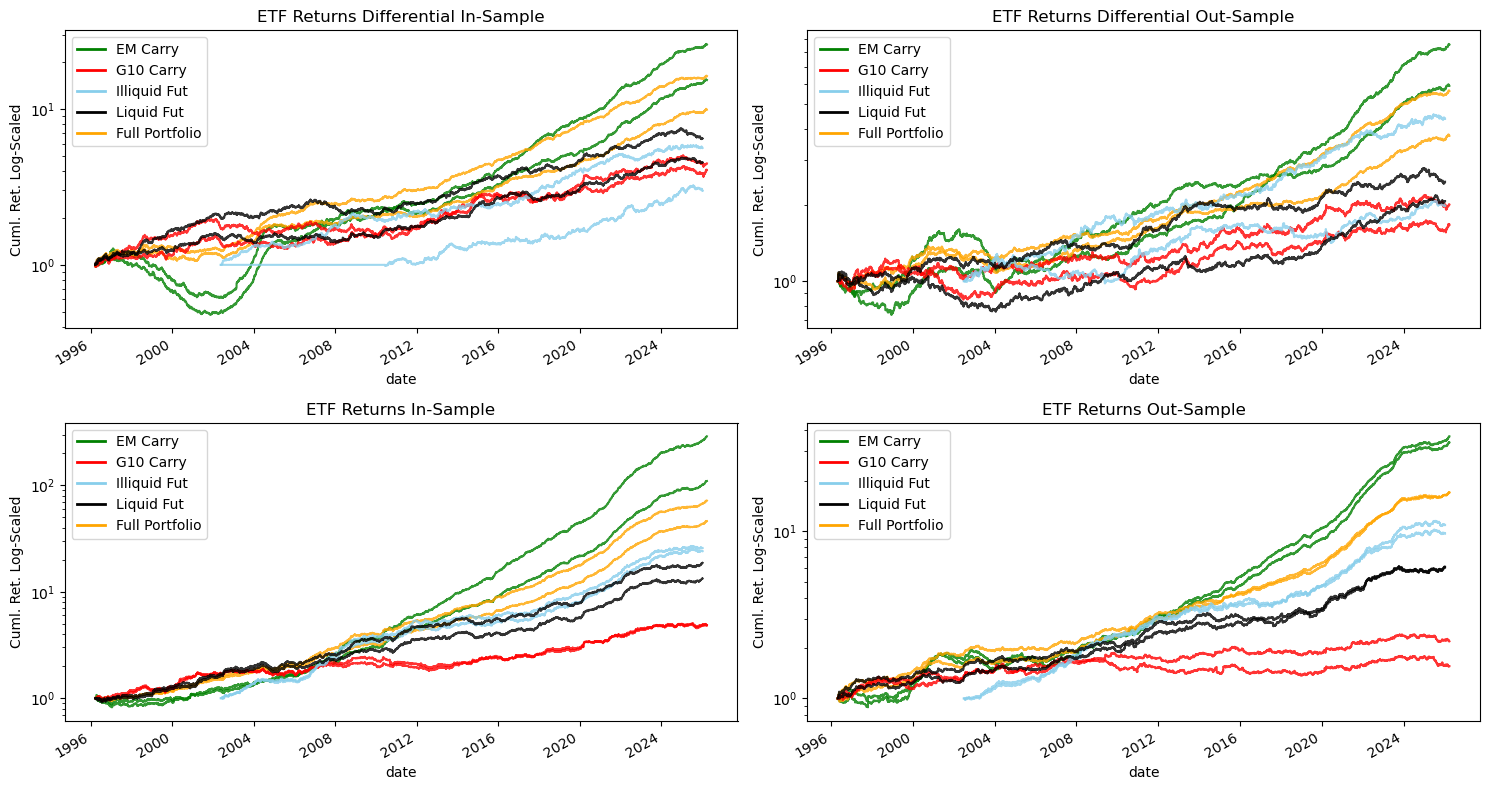

In [28]:
groups     = df_plot.name.drop_duplicates().sort_values().to_list()
plot_names = df_plot_guide.portfolio.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(groups) // 2, nrows = len(groups) // 2, figsize = (15,8))

for group, ax in zip(groups, axes.flatten()): 

    for plot in plot_names: 

        signal_name, sample = group.split(" ")

        port              = plot.split(" ")[0]
        df_plot_guide_tmp = (df_plot_guide
            .loc[lambda x: (x.name == group) & (x.portfolio == port)])

        strats = df_plot_guide_tmp.plot_name.to_list()
        color  = df_plot_guide_tmp.color.drop_duplicates().item()
        
        (df_plot
            .loc[lambda x: x.name == group]
            .assign(plot_name = lambda x: x.portfolio + " " + x.signal_type)
            .loc[lambda x: x.plot_name.isin(strats)]
            .pivot(index = "date", columns = "plot_name", values = "rtn")
            .fillna(0)
            .apply(lambda x: np.cumprod(1 + x))
            .plot(
                ax     = ax, 
                color  = color,
                logy   = True,
                alpha  = 0.8,
                legend = False,
                ylabel = "Cuml. Ret. Log-Scaled"))

    ax.set_title(RENAMER[signal_name] + " " + RENAMER[sample])
    ax.legend(handles = portfolio_handles)
    
plt.tight_layout()

In [39]:
group_cols = df_rtn.select_dtypes(include = "str").columns.to_list()

display(df_rtn
    .drop(columns = ["date"])
    .groupby(group_cols)
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index()
    .replace(RENAMER)
    .rename(columns = {
        "target"      : "Vol. Target",
        "sample_group": "Sample",
        "signal_type" : "Signal",
        "signal_name" : "Signal Name",
        "portfolio"   : "Group"})
    .pivot(index = ["Group", "Signal Name", "Signal"], columns = ["Vol. Target", "Sample"], values = "rtn"))

Vol. Target                                           Lagged             \
Sample                                             In-Sample Out-Sample   
Group          Signal Name              Signal                            
EM Carry       ETF Returns              Raw Return  3.069455   2.580093   
                                        Vol. Adj    2.619211   2.528253   
               ETF Returns Differential Raw Return  1.975725   1.686295   
                                        Vol. Adj    1.576336   1.387143   
Full Portfolio ETF Returns              Raw Return  2.683924   2.434048   
                                        Vol. Adj    2.486357   2.455368   
               ETF Returns Differential Raw Return  2.116812   1.671846   
                                        Vol. Adj    1.682317   1.242616   
G10 Carry      ETF Returns              Raw Return  0.864239   0.584409   
                                        Vol. Adj    0.875726   0.337515   
               ETF Returns Differential Raw Return  0.775008   0.455289   
                                        Vol. Adj    0.720785   0.368231   
Illiquid Fut   ETF Returns              Raw Return  2.214307   2.043821   
                                        Vol. Adj    2.198318   2.248270   
               ETF Returns Differential Raw Return  1.161465   1.262274   
                                        Vol. Adj    1.124983   0.667932   
Liquid Fut     ETF Returns              Raw Return  1.481595   1.199191   
                                        Vol. Adj    1.307913   1.189201   
               ETF Returns Differential Raw Return  1.015241   0.634616   
                                        Vol. Adj    0.860690   0.511135   

Vol. Target                                        Contemporaneous             
Sample                                                   In-Sample Out-Sample  
Group          Signal Name              Signal                                 
EM Carry       ETF Returns              Raw Return        3.256786   2.905537  
                                        Vol. Adj          2.846028   2.786992  
               ETF Returns Differential Raw Return        2.116497   1.875588  
                                        Vol. Adj          1.656846   1.468219  
Full Portfolio ETF Returns              Raw Return        2.780535   2.651811  
                                        Vol. Adj          2.635689   2.587772  
               ETF Returns Differential Raw Return        2.213639   1.814373  
                                        Vol. Adj          1.746319   1.354050  
G10 Carry      ETF Returns              Raw Return        0.855675   0.558452  
                                        Vol. Adj          0.860688   0.365815  
               ETF Returns Differential Raw Return        0.796507   0.477719  
                                        Vol. Adj          0.734950   0.381976  
Illiquid Fut   ETF Returns              Raw Return        2.234762   2.139705  
                                        Vol. Adj          2.247710   2.359444  
               ETF Returns Differential Raw Return        1.159548   1.335664  
                                        Vol. Adj          1.150093   0.546039  
Liquid Fut     ETF Returns              Raw Return        1.521890   1.235168  
                                        Vol. Adj          1.318650   1.235686  
               ETF Returns Differential Raw Return        1.009368   0.770725  
                                        Vol. Adj          0.896644   0.659784